# Week 6 - Day 1: Sprint 1 Baseline & Neural Network Architecture

I am starting Sprint 1 from my existing **Heart Disease Classification** project.

For Week 6, my previous classical ML models are the baseline. I am not limiting the baseline to only one model, so I will reproduce the Logistic Regression, Decision Tree, and Random Forest results using the same evaluation setup. The tuned Random Forest is still the strongest classical reference for the final neural-network comparison.

**Task:** Binary classification of `HeartDisease` (`0` = no heart disease, `1` = heart disease).

In this Day 1 notebook, I am not training a neural network yet. The goal is to lock the baseline, keep the evaluation setup clear, and review the neural-network architecture concepts before the training work later in Week 6.


## 1. Sprint 1 Goal and Backlog

### Sprint Goal

Use my existing Heart Disease Classification project as the starting point for Sprint 1, reproduce the classical ML baseline, and prepare the project for neural-network experiments later in Week 6.

### Day 1 Backlog

| Task | Acceptance Criteria |
|---|---|
| Verify dataset and cleaning rules | Same dataset schema and cleaning logic used in the existing project |
| Reproduce the train/test split | Stratified 80/20 split with `random_state=42` |
| Run a brief EDA | Target balance, data-quality issues, and a few important target associations are documented |
| Reproduce the baseline model set | Logistic Regression, Decision Tree, and Random Forest evaluated with the same 5-fold stratified CV |
| Record the strongest classical reference | Tuned Random Forest evaluated on the frozen held-out test set |
| Keep the test set fixed | The same test set is reserved for the later final neural-network comparison |
| Review Day 1 NN architecture | Neuron, layers, weights, biases, trainable parameters, and the meaning of "deep" are summarized |

The neural network training itself is for the later Week 6 days, not Day 1.


## 2. Imports and Project Paths

I use a small path resolver so the notebook can run from the repository layout or as a standalone notebook.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42

cwd = Path.cwd().resolve()


data_candidates = [cwd / "heart.csv", cwd / "data" / "heart.csv"]
for root in [cwd, *cwd.parents]:
    data_candidates.append(
        root / "final-project" / "heart-disease-classification" / "data" / "heart.csv"
    )

DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "heart.csv was not found. Keep the original final-project/data structure "
        "or place heart.csv beside this notebook / under a local data directory."
    )

OUTPUT_DIR = cwd / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATA_PATH)


Dataset: C:\Users\HP\Desktop\BinX-AI-ML-Internship\final-project\heart-disease-classification\data\heart.csv


## 3. Load and Verify the Dataset

I keep the original `heart.csv` unchanged. Any cleaning is done in memory using the same rules from the existing project.


In [2]:
df = pd.read_csv(DATA_PATH)

expected_columns = [
    "Age", "Sex", "ChestPainType", "RestingBP", "Cholesterol",
    "FastingBS", "RestingECG", "MaxHR", "ExerciseAngina",
    "Oldpeak", "ST_Slope", "HeartDisease",
]

assert list(df.columns) == expected_columns, "Unexpected dataset schema."

print("Shape:", df.shape)
print("Duplicated rows:", int(df.duplicated().sum()))
display(df.head())


Shape: (918, 12)
Duplicated rows: 0


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Dataset Audit

Before modeling, I check the feature types, missing values, and cardinality. The raw file has no visible `NaN` values and no duplicated rows. The invalid zero values are handled in the cleaning step.


In [3]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique_values": df.nunique(),
})

display(audit)


,dtype,missing,unique_values
Age,int64,0,50
Sex,str,0,2
ChestPainType,str,0,4
RestingBP,int64,0,67
Cholesterol,int64,0,222
FastingBS,int64,0,2
RestingECG,str,0,3
MaxHR,int64,0,119
ExerciseAngina,str,0,2
Oldpeak,float64,0,53


## 4. Data Quality and Cleaning

In the original project, I handled two suspicious zero values:

- `RestingBP = 0` is not a valid resting blood-pressure measurement.
- `Cholesterol = 0` is treated as unavailable, not as a real measurement.

I convert them to missing values here, then impute them later inside the preprocessing pipeline.


In [4]:
invalid_counts = pd.Series({
    "RestingBP = 0": int((df["RestingBP"] == 0).sum()),
    "Cholesterol = 0": int((df["Cholesterol"] == 0).sum()),
    "MaxHR = 0": int((df["MaxHR"] == 0).sum()),
}, name="count")

display(invalid_counts.to_frame())

df_clean = df.copy()
df_clean.loc[df_clean["RestingBP"] == 0, "RestingBP"] = np.nan
df_clean.loc[df_clean["Cholesterol"] == 0, "Cholesterol"] = np.nan

display(
    pd.DataFrame({
        "missing_after_cleaning": df_clean.isna().sum(),
        "missing_pct": (df_clean.isna().mean() * 100).round(2),
    }).query("missing_after_cleaning > 0")
)


,count
RestingBP = 0,1
Cholesterol = 0,172
MaxHR = 0,0


,missing_after_cleaning,missing_pct
RestingBP,1,0.11
Cholesterol,172,18.74


## 5. Frozen Train/Test Split

I reproduce the same train/test split used in the existing project.

The held-out test set stays fixed so the later neural network can be compared with the classical benchmark on the **same patients**.


In [5]:
X = df_clean.drop(columns="HeartDisease")
y = df_clean["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "samples": [len(X_train), len(X_test)],
    "positive_rate": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])

display(split_summary.round(4))


,samples,positive_rate
train,734,0.5531
test,184,0.5543


## 6. Brief EDA

The full project already has a larger EDA, so here I only do a focused Day 1 refresh on the training split.

The checks below answer three questions:

1. Is the target distribution reasonable?
2. Do important numeric features differ between the two target groups?
3. Which major categorical groups show clearly different heart-disease rates?

These are descriptive observations only, not causal claims.


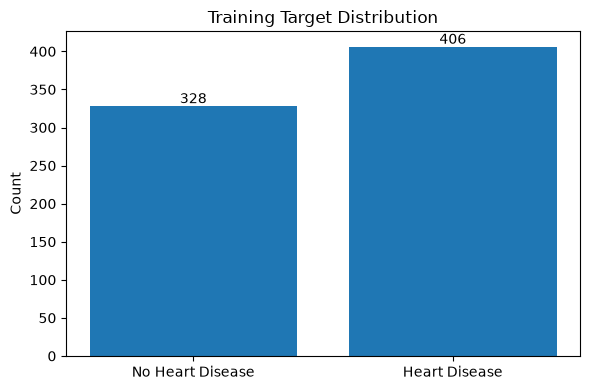

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
HeartDisease,,,,,
0,52.0,130.0,234.0,150.0,0.0
1,57.0,132.0,247.0,125.0,1.2


,feature,category,positive_rate,samples
0,ChestPainType,ASY,0.787,403
3,ChestPainType,TA,0.450,40
2,ChestPainType,NAP,0.335,155
1,ChestPainType,ATA,0.140,136
5,ExerciseAngina,Y,0.847,300
4,ExerciseAngina,N,0.350,434
7,ST_Slope,Flat,0.832,374
6,ST_Slope,Down,0.830,47
8,ST_Slope,Up,0.179,313


In [6]:
train_df = X_train.copy()
train_df["HeartDisease"] = y_train

# Target distribution
target_counts = train_df["HeartDisease"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["No Heart Disease", "Heart Disease"], target_counts.values)
ax.set_title("Training Target Distribution")
ax.set_ylabel("Count")
for i, value in enumerate(target_counts.values):
    ax.text(i, value + 4, str(value), ha="center")
fig.tight_layout()
plt.show()

# Numeric comparison by target
numeric_summary = (
    train_df.groupby("HeartDisease")[["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]]
    .median()
    .round(2)
)
display(numeric_summary)

# A compact categorical comparison: positive-target rate within each category
categorical_rates = []
for column in ["ChestPainType", "ExerciseAngina", "ST_Slope"]:
    rates = (
        train_df.groupby(column)["HeartDisease"]
        .agg(positive_rate="mean", samples="size")
        .reset_index()
    )
    rates.insert(0, "feature", column)
    rates = rates.rename(columns={column: "category"})
    categorical_rates.append(rates)

categorical_rates = pd.concat(categorical_rates, ignore_index=True)
categorical_rates["positive_rate"] = categorical_rates["positive_rate"].round(3)

display(categorical_rates.sort_values(["feature", "positive_rate"], ascending=[True, False]))


### EDA Notes

The training split is still reasonably balanced.

Patients in the positive class have a higher median age and `Oldpeak`, and a lower median `MaxHR` than patients in the negative class. The categorical summaries also show clear differences across `ChestPainType`, `ExerciseAngina`, and `ST_Slope`.

These patterns support using both numeric and categorical predictors. I am treating them as dataset associations only, not medical or diagnostic claims.

Because this dataset is small and tabular, I should not assume a neural network will automatically beat the classical models. It needs to be tested against this baseline.


## 7. Preprocessing and Feature Engineering

I use the same preprocessing logic from the existing project:

- engineered cardiac/interaction features,
- median imputation + standardization for numeric features,
- most-frequent imputation + one-hot encoding for categorical features.

The preprocessing is fitted inside the pipeline, so cross-validation does not leak information from the validation folds.


In [7]:
def add_engineered_features(X_input):
    X_new = X_input.copy()

    expected_max_hr = 220 - X_new["Age"]
    X_new["MaxHRRatio"] = X_new["MaxHR"] / expected_max_hr.replace(0, np.nan)
    X_new["OldpeakPositive"] = (X_new["Oldpeak"] > 0).astype(int)
    X_new["ExerciseOldpeak"] = (
        X_new["Oldpeak"] * (X_new["ExerciseAngina"] == "Y").astype(int)
    )
    X_new["AgeGroup"] = pd.cut(
        X_new["Age"],
        bins=[0, 45, 55, 65, 120],
        labels=["under_45", "45_55", "56_65", "over_65"],
        include_lowest=True,
    ).astype("object")

    return X_new


numeric_features = [
    "Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR",
    "Oldpeak", "MaxHRRatio", "OldpeakPositive", "ExerciseOldpeak",
]

categorical_features = [
    "Sex", "ChestPainType", "RestingECG",
    "ExerciseAngina", "ST_Slope", "AgeGroup",
]

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_preprocessor, numeric_features),
    ("cat", categorical_preprocessor, categorical_features),
])


def make_pipeline(model):
    return Pipeline([
        ("features", FunctionTransformer(add_engineered_features, validate=False)),
        ("preprocess", preprocessor),
        ("model", model),
    ])


## 8. Baseline Model Comparison

The baseline is not only one model. I reproduce the three classical models from the existing project:

- Logistic Regression
- Decision Tree
- Random Forest

I evaluate each model with the same **5-fold stratified cross-validation** on the training set only.


In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": make_pipeline(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    ),
    "Decision Tree": make_pipeline(
        DecisionTreeClassifier(random_state=RANDOM_STATE)
    ),
    "Random Forest": make_pipeline(
        RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    ),
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

rows = []

for model_name, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )

    row = {"model": model_name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    rows.append(row)

cv_results = (
    pd.DataFrame(rows)
    .sort_values("roc_auc_mean", ascending=False)
    .reset_index(drop=True)
)

display(cv_results.round(4))
cv_results.to_csv(OUTPUT_DIR / "day1_baseline_cv_results.csv", index=False)


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Random Forest,0.8501,0.0272,0.8593,0.0435,0.8771,0.0459,0.8663,0.0229,0.9287,0.0280
1,Logistic Regression,0.8447,0.0215,0.8568,0.0382,0.8670,0.0237,0.8610,0.0156,0.9255,0.0307
2,Decision Tree,0.8160,0.0372,0.8429,0.0431,0.8228,0.0412,0.8320,0.0333,0.8153,0.0382


### Baseline Results

Using the fixed 5-fold stratified cross-validation setup on the training set:

| Model | Mean CV F1 | Mean CV ROC-AUC |
|---|---:|---:|
| Logistic Regression | **0.8610** | **0.9255** |
| Decision Tree | **0.8320** | **0.8153** |
| Random Forest | **0.8663** | **0.9287** |

For Week 6, I consider the **existing classical-model set** as the baseline, not only one selected algorithm.

`Logistic Regression` is the simplest reference, while `Random Forest` is the strongest untuned model here. The tuned Random Forest from the previous project remains the strongest classical reference for the final neural-network comparison.


## 9. Existing Strong Classical Reference

The previous project already included hyperparameter tuning, so I do not need to repeat the full grid search for Day 1.

The selected Random Forest configuration was:

- `n_estimators=100`
- `max_depth=None`
- `min_samples_leaf=4`
- `max_features="sqrt"`

I refit this configuration on the same training set and evaluate it on the same frozen test set to reproduce the final benchmark.


In [9]:
benchmark_model = make_pipeline(
    RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=4,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
)

benchmark_model.fit(X_train, y_train)

benchmark_pred = benchmark_model.predict(X_test)
benchmark_proba = benchmark_model.predict_proba(X_test)[:, 1]

benchmark_metrics = pd.DataFrame([{
    "model": "Tuned Random Forest",
    "accuracy": accuracy_score(y_test, benchmark_pred),
    "precision": precision_score(y_test, benchmark_pred),
    "recall": recall_score(y_test, benchmark_pred),
    "f1": f1_score(y_test, benchmark_pred),
    "roc_auc": roc_auc_score(y_test, benchmark_proba),
}])

display(benchmark_metrics.round(4))
benchmark_metrics.to_csv(OUTPUT_DIR / "day1_strong_benchmark.csv", index=False)


,model,accuracy,precision,recall,f1,roc_auc
0,Tuned Random Forest,0.8696,0.8679,0.902,0.8846,0.9173


### Reference Score for the Later Neural Network

On the frozen held-out test set, the tuned Random Forest reproduces:

- **F1 = 0.8846**
- **ROC-AUC = 0.9173**
- Accuracy = 0.8696
- Precision = 0.8679
- Recall = 0.9020

For the final Week 6 comparison, **F1 = 0.8846** is the strongest existing classical reference to beat on this exact test set.

I should not use the test set to choose the neural-network architecture or hyperparameters. Those choices should come from training/validation results, and the frozen test set should only be used again for the final comparison.


## 10. Baseline Locked for Week 6

The Day 1 baseline is now clear:

- **Dataset:** same `heart.csv`
- **Evaluation split:** same stratified 80/20 split
- **Baseline model set:** Logistic Regression, Decision Tree, Random Forest
- **Strongest existing classical reference:** tuned Random Forest
- **Final held-out reference:** F1 = **0.8846**, ROC-AUC = **0.9173**
- **Primary Week 6 comparison metrics:** F1 and ROC-AUC

The neural network should be developed using the training portion only. I should take a validation split from that training portion for architecture and tuning decisions, and keep the held-out test set frozen until the final comparison.


## 11. Day 1 Neural Network Architecture Review

A neuron computes a weighted sum, adds a bias, then applies an activation:

\[
z = xW + b
\]

\[
a = f(z)
\]

- **Input layer:** receives the processed feature vector.
- **Hidden layers:** learn intermediate representations.
- **Output layer:** produces the final prediction.
- **Weights and biases:** trainable parameters learned from data.
- **Depth:** number of learned hidden layers.
- **Width:** number of neurons in a layer.
- **Deep learning:** uses multiple learned hidden layers.

If I stack only linear transformations without nonlinear activations, the result can still collapse into one linear transformation. Nonlinear activations are what allow hidden layers to learn nonlinear representations.

The **parameters** (`weights`, `biases`) are learned during training. Architecture choices like the number of hidden layers and neurons per layer are **hyperparameters** that I choose and tune.

No neural network is trained in this Day 1 notebook.


In [10]:
# Fit preprocessing on the training data only to inspect the future NN input size.
feature_transformer = FunctionTransformer(add_engineered_features, validate=False)
X_train_engineered = feature_transformer.fit_transform(X_train)
X_train_processed = preprocessor.fit_transform(X_train_engineered)

print("Original feature count:", X_train.shape[1])
print("Processed feature count:", X_train_processed.shape[1])
print("Processed training shape:", X_train_processed.shape)


Original feature count: 11
Processed feature count: 27
Processed training shape: (734, 27)


For this dataset, the processed feature vector has 27 values per patient.

A later compact network could start conceptually as:

```text
27 processed inputs
        ↓
small hidden layer(s)
        ↓
1 binary output
```

The exact hidden-layer sizes, activations, loss function, optimizer, dropout, and training configuration belong to the later Week 6 work. I should choose them using validation results, not the test set.


## Day 1 Requirement Check

| Week 6 Day 1 Requirement | Notebook Evidence |
|---|---|
| Confirm Sprint 1 goal and backlog | Section 1 |
| Finalize project dataset | Sections 3-5 |
| Complete a brief EDA | Section 6 |
| Train/establish a baseline and record metrics | Sections 8-10 |
| State the score later models must beat | Section 9 |
| Understand neuron/layers/weights/biases | Section 11 |
| Commit through feature branch / draft PR | Git workflow below |

This notebook covers the technical Day 1 requirements. The Git branch, commit, and draft pull request are repository actions to complete when I add the notebook to GitHub.


## 12. Day 1 Summary

Day 1 does not restart the capstone from zero. I use my existing Heart Disease Classification work and make the baseline explicit:

- the same dataset and cleaning rules are preserved,
- the original train/test protocol is reproduced,
- a concise training-only EDA refresh is documented,
- Logistic Regression, Decision Tree, and Random Forest form the classical baseline set,
- the tuned Random Forest remains the strongest existing classical reference,
- the held-out F1 reference is **0.8846**,
- the neural-network architecture concepts required for Day 1 are documented,
- the test set is frozen for the later final neural-network comparison.
